In [ ]:
#  Bước 2.0 — Nhập & Nạp dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
APPROVED_COLOR = "#2ecc71"
REJECTED_COLOR = "#e74c3c"
NEUTRAL_COLOR  = "#3498db"

df = pd.read_csv("clean_loan_data.csv")

# Phần 1 mới: không có Total_Income, EMI — có thêm Property_Area
NUMERIC_COLS  = ["ApplicantIncome", "CoapplicantIncome",
                 "LoanAmount", "Loan_Amount_Term"]   # 4 biến liên tục
ORDINAL_COLS  = ["Credit_History", "Property_Area"]  # 2 biến rời rạc có thứ tự
TARGET_COL    = "Loan_Status"

print(f"Dữ liệu đầu vào : {df.shape[0]} dòng × {df.shape[1]} cột")
print(f"Các cột         : {df.columns.tolist()}")
print(f"Tỉ lệ Duyệt/TừChối : {df[TARGET_COL].value_counts().to_dict()}")
print(f"Property_Area phân bố: {df['Property_Area'].value_counts().sort_index().to_dict()}")
print(f"  (0=Rural, 1=Urban, 2=Semiurban)")
df.head()

Dữ liệu đầu vào : 614 dòng × 7 cột
Các cột         : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']
Tỉ lệ Duyệt/TừChối : {1: 422, 0: 192}
Property_Area phân bố: {0: 179, 1: 202, 2: 233}
  (0=Rural, 1=Urban, 2=Semiurban)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,5849,0.0,128.0,360.0,1.0,1,1
1,4583,1508.0,128.0,360.0,1.0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1
3,2583,2358.0,120.0,360.0,1.0,1,1
4,6000,0.0,141.0,360.0,1.0,1,1


In [ ]:
# Bước 2.1 — Thống kê mô tả + Cờ tự động
pd.set_option("display.float_format", "{:.3f}".format)

all_cols = NUMERIC_COLS + ORDINAL_COLS
desc = df[all_cols].describe(percentiles=[.25, .5, .75, .95]).T
desc["skewness"] = df[all_cols].skew()
desc["kurtosis"] = df[all_cols].kurt()

print("=" * 70)
print("THỐNG KÊ MÔ TẢ")
print("=" * 70)
print(desc[["mean", "std", "min", "25%", "50%", "75%", "95%", "max",
            "skewness", "kurtosis"]])

print("\n" + "=" * 70)
print("⚠  PHÂN TÍCH TỰ ĐỘNG — CÁC CỘT CẦN LƯU Ý")
print("=" * 70)

# Thu thập kết quả động — không hardcode
cols_iqr       = []   # sẽ lọc IQR
cols_mannwhit  = []   # dự kiến Mann-Whitney
cols_ttest     = []   # dự kiến T-test

for col in NUMERIC_COLS:
    skew = df[col].skew()
    kurt = df[col].kurt()
    flags = []

    if abs(skew) > 3:
        flags.append(f"lệch {'phải' if skew > 0 else 'trái'} NẶNG (skew={skew:.2f})")
    elif abs(skew) > 1:
        flags.append(f"lệch {'phải' if skew > 0 else 'trái'} vừa (skew={skew:.2f})")
    else:
        flags.append(f"gần chuẩn (skew={skew:.2f})")

    if kurt > 10:
        flags.append(f"đuôi rất nặng (kurt={kurt:.1f}) → nhiều outlier")

    if abs(skew) > 1:
        flags.append("→ khả năng cao cần Mann-Whitney (Bước 2.3 xác nhận)")
        cols_mannwhit.append(col)
        cols_iqr.append(col)
    else:
        flags.append("→ có thể dùng T-test, Bước 2.3 sẽ kiểm tra")
        cols_ttest.append(col)
        cols_iqr.append(col)

    status = "🔴" if abs(skew) > 3 else ("🟡" if abs(skew) > 1 else "🟢")
    print(f"  {status} {col:<22}: {' | '.join(flags)}")

print()

# Biến rời rạc
cols_chisq = []
for col in ORDINAL_COLS:
    skew = df[col].skew()
    kurt = df[col].kurt()
    cols_chisq.append(col)

    if col == "Credit_History":
        n_good   = int((df[col] == 1).sum())
        n_bad    = int((df[col] == 0).sum())
        pct_good = n_good / len(df) * 100
        print(f"  ℹ️  {col:<22}: biến nhị phân (0=Xấu, 1=Tốt)")
        print(f"  {'':26}  Tốt (1) = {n_good} ({pct_good:.1f}%)  |  Xấu (0) = {n_bad} ({100-pct_good:.1f}%)")
        print(f"  {'':26}  skew={skew:.2f} âm do đa số = 1 — bình thường, KHÔNG cần xử lý")
        print(f"  {'':26}  → Bước 2.3 sẽ dùng Chi-square để kiểm định")

    elif col == "Property_Area":
        n_rural = int((df[col] == 0).sum())
        n_urban = int((df[col] == 1).sum())
        n_semi  = int((df[col] == 2).sum())
        print()
        print(f"  ℹ️  {col:<22}: biến thứ tự 3 giá trị (0=Rural, 1=Urban, 2=Semiurban)")
        print(f"  {'':26}  Rural={n_rural}  |  Urban={n_urban}  |  Semiurban={n_semi}")
        print(f"  {'':26}  skew={skew:.2f}, kurt={kurt:.2f} — phân bố dẹt, bình thường với biến phân loại")
        print(f"  {'':26}  → Bước 2.3 sẽ dùng Chi-square để kiểm định")

# Tóm tắt hoàn toàn động — không hardcode tên cột
print()
print("─" * 70)
print("📌 KẾ HOẠCH DỰ KIẾN — Căn cứ từ phân tích trên:")
print("─" * 70)
print(f"  Lọc outlier IQR × 3.0     : {cols_iqr}")
print(f"  Không lọc outlier          : {ORDINAL_COLS}  (biến rời rạc)")
print()
print("  Dự kiến kiểm định (Bước 2.3 xác nhận bằng Shapiro-Wilk):")
if cols_mannwhit:
    print(f"  → Dự kiến Mann-Whitney     : {cols_mannwhit}")
if cols_ttest:
    print(f"  → Dự kiến T-test           : {cols_ttest}")
print(f"  → Chi-square               : {cols_chisq}")

THỐNG KÊ MÔ TẢ
                      mean      std     min      25%      50%      75%  \
ApplicantIncome   5403.459 6109.042 150.000 2877.500 3812.500 5795.000   
CoapplicantIncome 1621.246 2926.248   0.000    0.000 1188.500 2297.250   
LoanAmount         145.752   84.107   9.000  100.250  128.000  164.750   
Loan_Amount_Term   342.410   64.429  12.000  360.000  360.000  360.000   
Credit_History       0.855    0.352   0.000    1.000    1.000    1.000   
Property_Area        1.088    0.815   0.000    0.000    1.000    2.000   

                        95%       max  skewness  kurtosis  
ApplicantIncome   14583.000 81000.000     6.540    60.541  
CoapplicantIncome  4997.400 41667.000     7.492    84.956  
LoanAmount          293.400   700.000     2.743    10.937  
Loan_Amount_Term    360.000   480.000    -2.402     6.925  
Credit_History        1.000     1.000    -2.022     2.095  
Property_Area         2.000     2.000    -0.163    -1.477  

⚠  PHÂN TÍCH TỰ ĐỘNG — CÁC CỘT CẦN LƯU Ý
  🔴 

NHÓM 1 — Biến liên tục: Lọc bằng IQR × 3.0
─────────────────────────────────────────────────────────────────
  ApplicantIncome       : [-5875.0 ; 14547.5]  →  32 outliers (5.2%)
  CoapplicantIncome     : [-6891.8 ; 9189.0]  →  6 outliers (1.0%)
  LoanAmount            : [-93.2 ; 358.2]  →  19 outliers (3.1%)

NHÓM 2 — Biến rời rạc: Kiểm tra giá trị hợp lệ (không dùng IQR)
─────────────────────────────────────────────────────────────────
  Loan_Amount_Term — Phân bố:
Loan_Amount_Term
12.000       1
36.000       2
60.000       2
84.000       4
120.000      3
180.000     44
240.000      4
300.000     13
360.000    526
480.000     15
  Dòng không hợp lệ: 0
  ✅ Tất cả kỳ hạn hợp lệ — KHÔNG xóa dòng nào

  Property_Area — Phân bố:
Property_Area
Rural        179
Urban        202
Semiurban    233
  Dòng không hợp lệ: 0
  ✅ Tất cả khu vực hợp lệ — KHÔNG xóa dòng nào

  Credit_History — Phân bố: {1.0: 525, 0.0: 89}
  ✅ Biến nhị phân — KHÔNG lọc outlier

──────────────────────────────────────────

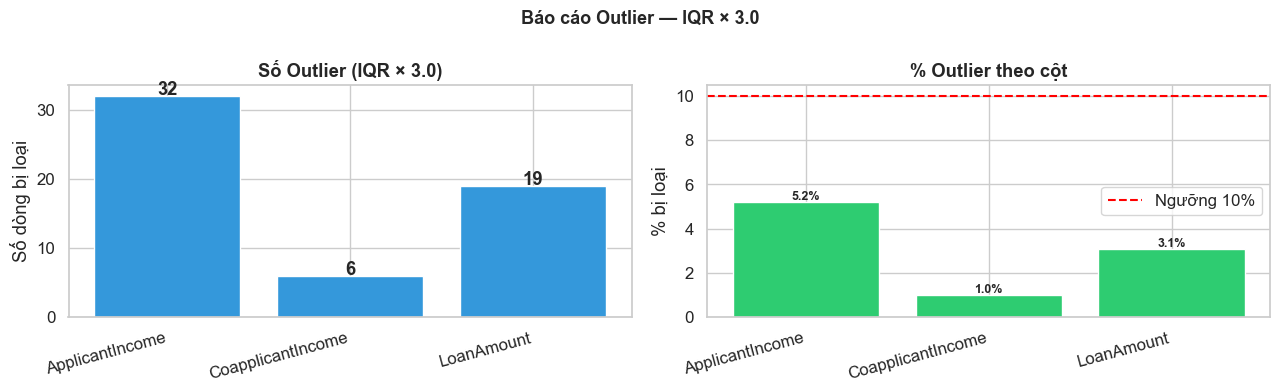

In [ ]:
# Bước 2.2 — Lọc ngoại lệ (IQR × 3.0 + Kiểm tra nghiệp vụ)
IQR_MULTIPLIER = 3.0

outlier_report = {}
bounds         = {}
mask_keep      = pd.Series(True, index=df.index)

# ── NHÓM 1: Biến liên tục → IQR ────────────────────────────
print(f"NHÓM 1 — Biến liên tục: Lọc bằng IQR × {IQR_MULTIPLIER}")
print("─" * 65)

CONTINUOUS_COLS = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
# Loan_Amount_Term xử lý riêng như nhóm 2

for col in CONTINUOUS_COLS:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - IQR_MULTIPLIER * IQR
    upper = Q3 + IQR_MULTIPLIER * IQR
    is_out = (df[col] < lower) | (df[col] > upper)
    outlier_report[col] = is_out.sum()
    bounds[col]         = (lower, upper)
    mask_keep          &= ~is_out
    print(f"  {col:<22}: [{lower:.1f} ; {upper:.1f}]  →  {is_out.sum()} outliers ({is_out.mean()*100:.1f}%)")

# ── NHÓM 2: Biến rời rạc nghiệp vụ → Kiểm tra tập giá trị ─
print("\nNHÓM 2 — Biến rời rạc: Kiểm tra giá trị hợp lệ (không dùng IQR)")
print("─" * 65)

# Loan_Amount_Term
VALID_TERMS = {12, 36, 60, 84, 120, 180, 240, 300, 360, 480}
invalid_term = ~df["Loan_Amount_Term"].isin(VALID_TERMS)
print(f"  Loan_Amount_Term — Phân bố:\n{df['Loan_Amount_Term'].value_counts().sort_index().to_string()}")
print(f"  Dòng không hợp lệ: {invalid_term.sum()}")
if invalid_term.sum() > 0:
    mask_keep &= ~invalid_term
    print(f"  → Xóa {invalid_term.sum()} dòng")
else:
    print("  ✅ Tất cả kỳ hạn hợp lệ — KHÔNG xóa dòng nào")

# Property_Area
VALID_AREAS = {0, 1, 2}   # Rural=0, Urban=1, Semiurban=2
invalid_area = ~df["Property_Area"].isin(VALID_AREAS)
print(f"\n  Property_Area — Phân bố:\n{df['Property_Area'].value_counts().sort_index().rename({0:'Rural',1:'Urban',2:'Semiurban'}).to_string()}")
print(f"  Dòng không hợp lệ: {invalid_area.sum()}")
if invalid_area.sum() > 0:
    mask_keep &= ~invalid_area
else:
    print("  ✅ Tất cả khu vực hợp lệ — KHÔNG xóa dòng nào")

# Credit_History
invalid_credit = ~df["Credit_History"].isin([0.0, 1.0])
print(f"\n  Credit_History — Phân bố: {df['Credit_History'].value_counts().to_dict()}")
print(f"  ✅ Biến nhị phân — KHÔNG lọc outlier")

# Tổng kết
n_before  = len(df)
df_clean  = df[mask_keep].copy().reset_index(drop=True)
n_after   = len(df_clean)
approved  = df_clean[df_clean[TARGET_COL] == 1]
rejected  = df_clean[df_clean[TARGET_COL] == 0]

print(f"\n{'─'*65}")
print(f"  Trước lọc : {n_before} dòng")
print(f"  Sau lọc   : {n_after}  dòng  (giữ {n_after/n_before*100:.1f}%)")
pct = (n_before - n_after) / n_before * 100
print(f"  {'✅ Hợp lý' if pct < 10 else '⚠️  Hơi nhiều, cân nhắc tăng hệ số'} — loại {pct:.1f}%")

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bars = axes[0].bar(outlier_report.keys(), outlier_report.values(),
                   color=NEUTRAL_COLOR, edgecolor="white")
for bar, val in zip(bars, outlier_report.values()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title(f"Số Outlier (IQR × {IQR_MULTIPLIER})", fontweight='bold')
axes[0].set_ylabel("Số dòng bị loại")
axes[0].set_xticklabels(outlier_report.keys(), rotation=15, ha='right')

pct_vals = [v/n_before*100 for v in outlier_report.values()]
colors   = [REJECTED_COLOR if p > 10 else APPROVED_COLOR for p in pct_vals]
axes[1].bar(outlier_report.keys(), pct_vals, color=colors, edgecolor="white")
axes[1].axhline(10, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng 10%')
for bar, val in zip(axes[1].patches, pct_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{val:.1f}%", ha='center', fontweight='bold', fontsize=9)
axes[1].set_title("% Outlier theo cột", fontweight='bold')
axes[1].set_ylabel("% bị loại")
axes[1].set_xticklabels(outlier_report.keys(), rotation=15, ha='right')
axes[1].legend()

plt.suptitle(f"Báo cáo Outlier — IQR × {IQR_MULTIPLIER}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Bước 2.3 — Kiểm tra danh sách thống kê
ALPHA        = 0.05
test_results = []

print("=" * 70)
print("KIỂM ĐỊNH THỐNG KÊ — Biến liên tục vs Loan_Status")
print("Quy tắc: Shapiro-Wilk p < 0.05 → không chuẩn → Mann-Whitney")
print("=" * 70)

for col in NUMERIC_COLS:
    a_vals = approved[col].dropna()
    r_vals = rejected[col].dropna()
    _, p_a    = stats.shapiro(a_vals)
    _, p_r    = stats.shapiro(r_vals)
    is_normal = (p_a > 0.05) and (p_r > 0.05)

    if is_normal:
        stat, p_val = stats.ttest_ind(a_vals, r_vals)
        test_name   = "T-test      "
        reason      = f"chuẩn (p_shapiro: {p_a:.3f}, {p_r:.3f})"
    else:
        stat, p_val = stats.mannwhitneyu(a_vals, r_vals, alternative='two-sided')
        test_name   = "Mann-Whitney"
        reason      = f"không chuẩn (p_shapiro: {p_a:.3f}, {p_r:.3f})"

    sig = "✔ Có ý nghĩa" if p_val < ALPHA else "✘ Không ý nghĩa"
    test_results.append({"Cột": col, "Kiểm định": test_name.strip(),
                         "p-value": round(p_val, 5), "Kết quả": sig})
    print(f"\n  {col}")
    print(f"    Dùng   : {test_name}  ({reason})")
    print(f"    p-value: {p_val:.5f}  →  {sig}")

df_test = pd.DataFrame(test_results)

# Chi-square cho Credit_History
print("\n" + "=" * 70)
print("CHI-SQUARE — Credit_History vs Loan_Status")
ct_cr = pd.crosstab(df_clean["Credit_History"], df_clean[TARGET_COL])
chi2_cr, p_cr, dof_cr, _ = stats.chi2_contingency(ct_cr)
print(f"  χ² = {chi2_cr:.4f}  |  p = {p_cr:.2e}  |  dof = {dof_cr}")
print(f"  → {'✔ CÓ ý nghĩa — Credit_History quyết định mạnh nhất!' if p_cr < ALPHA else '✘'}")

# Chi-square cho Property_Area
print("\n" + "=" * 70)
print("CHI-SQUARE — Property_Area vs Loan_Status")
ct_pa = pd.crosstab(df_clean["Property_Area"], df_clean[TARGET_COL])
print(f"  Bảng chéo (0=Rural, 1=Urban, 2=Semiurban):\n{ct_pa}")
chi2_pa, p_pa, dof_pa, _ = stats.chi2_contingency(ct_pa)
print(f"\n  χ² = {chi2_pa:.4f}  |  p = {p_pa:.4f}  |  dof = {dof_pa}")
print(f"  → {'✔ CÓ ý nghĩa — Khu vực bất động sản ảnh hưởng đến phê duyệt' if p_pa < ALPHA else '✘ Không ý nghĩa'}")

# Kết luận tổng hợp
print("\n" + "─" * 70)
print("📌 KẾT LUẬN — Dùng cho Phần 3 & 4:")
sig_cols = [r["Cột"] for _, r in df_test.iterrows() if "Có" in r["Kết quả"]]
no_cols  = [r["Cột"] for _, r in df_test.iterrows() if "Không" in r["Kết quả"]]
if sig_cols: print(f"  Phân biệt được 2 nhóm: {sig_cols}")
if no_cols:  print(f"  Không phân biệt riêng lẻ: {no_cols}")
print(f"  → KNN cần kết hợp nhiều chiều mới hiệu quả")
print(f"  Credit_History (χ²={chi2_cr:.1f}, p≈0) → KHÔNG được bỏ khỏi model")
print(f"  Property_Area (χ²={chi2_pa:.2f}, p={p_pa:.4f}) → {'Giữ lại' if p_pa < ALPHA else 'Cân nhắc bỏ'}")

KIỂM ĐỊNH THỐNG KÊ — Biến liên tục vs Loan_Status
Quy tắc: Shapiro-Wilk p < 0.05 → không chuẩn → Mann-Whitney

  ApplicantIncome
    Dùng   : Mann-Whitney  (không chuẩn (p_shapiro: 0.000, 0.000))
    p-value: 0.63148  →  ✘ Không ý nghĩa

  CoapplicantIncome
    Dùng   : Mann-Whitney  (không chuẩn (p_shapiro: 0.000, 0.000))
    p-value: 0.11075  →  ✘ Không ý nghĩa

  LoanAmount
    Dùng   : Mann-Whitney  (không chuẩn (p_shapiro: 0.000, 0.000))
    p-value: 0.73811  →  ✘ Không ý nghĩa

  Loan_Amount_Term
    Dùng   : Mann-Whitney  (không chuẩn (p_shapiro: 0.000, 0.000))
    p-value: 0.58577  →  ✘ Không ý nghĩa

CHI-SQUARE — Credit_History vs Loan_Status
  χ² = 169.8948  |  p = 7.80e-39  |  dof = 1
  → ✔ CÓ ý nghĩa — Credit_History quyết định mạnh nhất!

CHI-SQUARE — Property_Area vs Loan_Status
  Bảng chéo (0=Rural, 1=Urban, 2=Semiurban):
Loan_Status     0    1
Property_Area         
0              63  103
1              64  125
2              50  166

  χ² = 10.7005  |  p = 0.0047  |  d

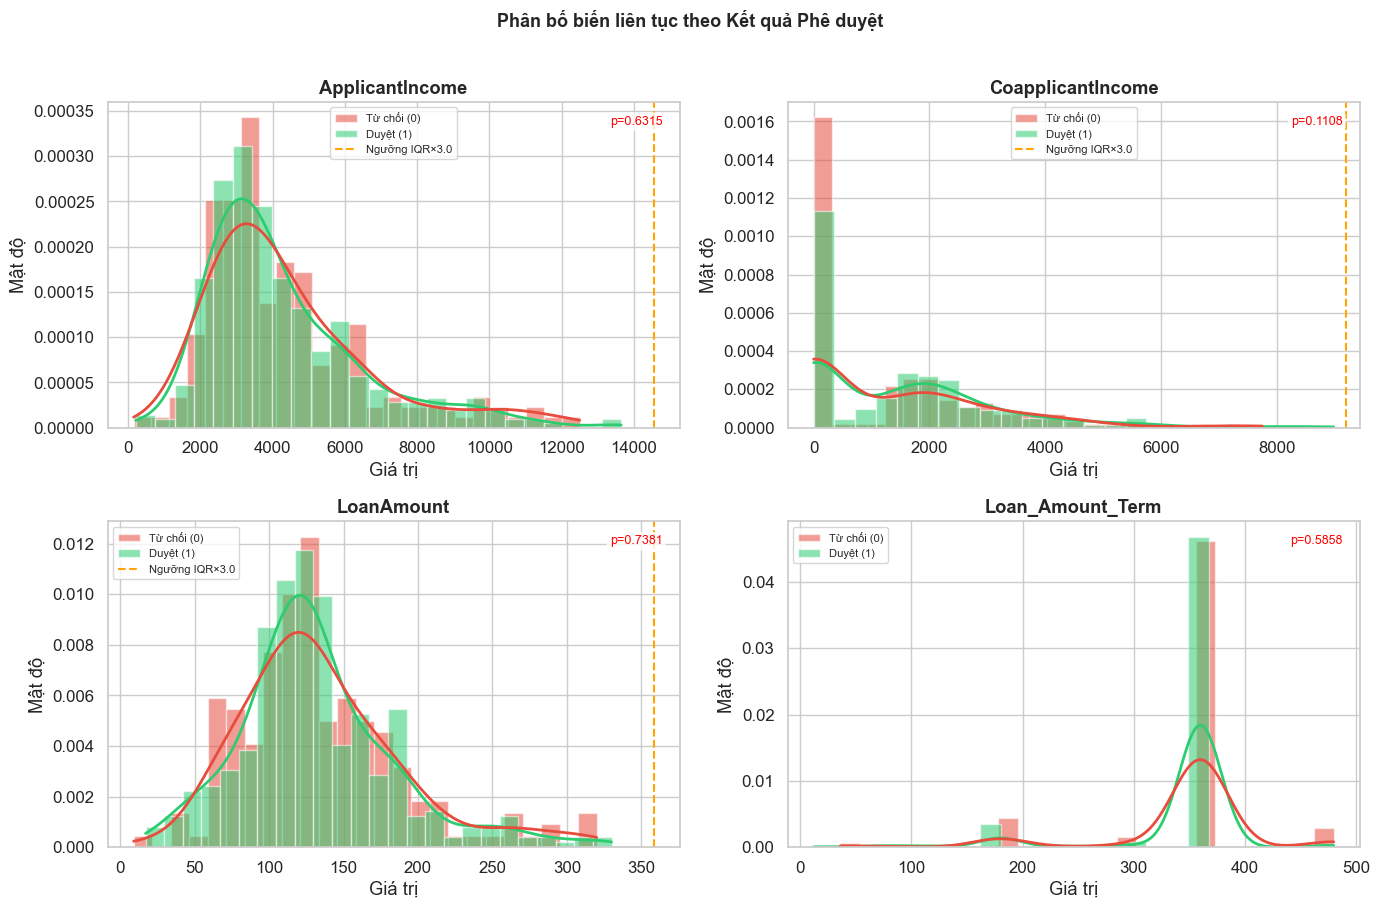

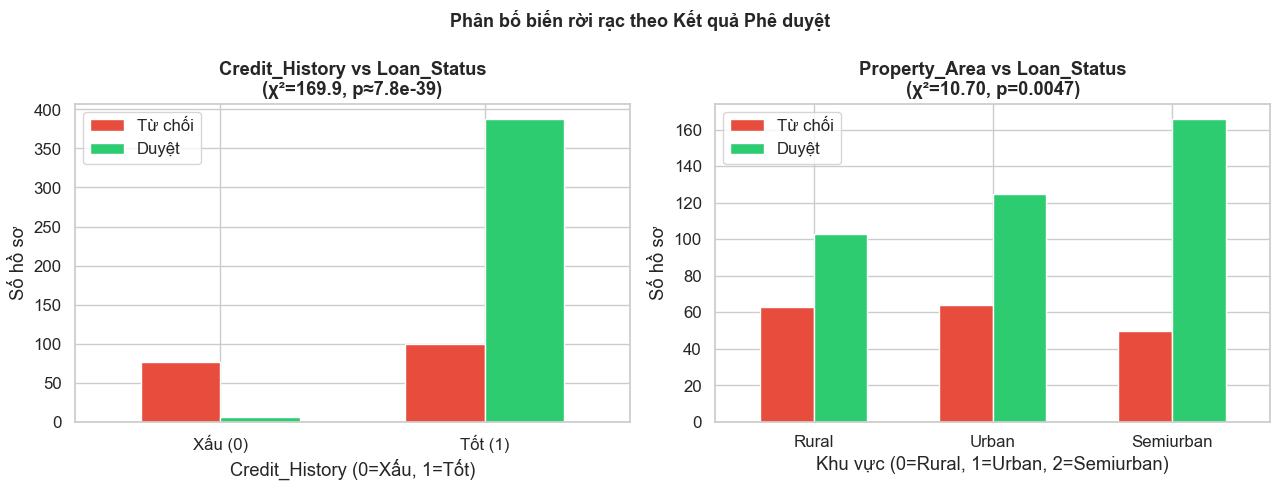

📌 KẾT LUẬN Histogram:
  ⚪ ApplicantIncome: median chênh 0% → 2 nhóm phân bố gần nhau
  ⚪ CoapplicantIncome: median chênh 0% → 2 nhóm phân bố gần nhau
  ⚪ LoanAmount: median chênh 2% → 2 nhóm phân bố gần nhau
  ⚪ Loan_Amount_Term: median chênh 0% → 2 nhóm phân bố gần nhau

  Tỉ lệ duyệt theo Property_Area:
    Rural       : 62.0% duyệt  (166 hồ sơ)
    Urban       : 66.1% duyệt  (189 hồ sơ)
    Semiurban   : 76.9% duyệt  (216 hồ sơ)


In [ ]:
# Bước 2.4 — Biểu đồ + KDE
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax     = axes[i]
    a_data = approved[col]
    r_data = rejected[col]

    ax.hist(r_data, bins=25, alpha=0.55, color=REJECTED_COLOR,
            density=True, label="Từ chối (0)", edgecolor="white")
    ax.hist(a_data, bins=25, alpha=0.55, color=APPROVED_COLOR,
            density=True, label="Duyệt (1)", edgecolor="white")

    for data, color in [(a_data, APPROVED_COLOR), (r_data, REJECTED_COLOR)]:
        kde_x = np.linspace(data.min(), data.max(), 200)
        ax.plot(kde_x, stats.gaussian_kde(data)(kde_x), color=color, linewidth=2)

    # Ngưỡng IQR — chỉ với cột có trong bounds
    lower_b, upper_b = bounds.get(col, (None, None))
    if upper_b is not None:
        ax.axvline(upper_b, color='orange', linestyle='--', linewidth=1.5,
                   label=f'Ngưỡng IQR×{IQR_MULTIPLIER}')
        if lower_b is not None and lower_b > ax.get_xlim()[0]:
            ax.axvline(lower_b, color='orange', linestyle='--', linewidth=1.5)

    p_row = df_test[df_test["Cột"] == col]
    if not p_row.empty:
        p_val = p_row["p-value"].values[0]
        c_ann = "green" if p_val < ALPHA else "red"
        ax.annotate(f"p={p_val:.4f}", xy=(0.97, 0.93), xycoords='axes fraction',
                    ha='right', fontsize=9, color=c_ann,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    ax.set_title(col, fontweight='bold')
    ax.set_xlabel("Giá trị")
    ax.set_ylabel("Mật độ")
    ax.legend(fontsize=8)

plt.suptitle("Phân bố biến liên tục theo Kết quả Phê duyệt",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Biểu đồ riêng cho biến rời rạc — dùng Countplot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Credit_History
ct_data = df_clean.groupby(["Credit_History", TARGET_COL]).size().unstack(fill_value=0)
ct_data.plot(kind='bar', color=[REJECTED_COLOR, APPROVED_COLOR], ax=axes[0],
             edgecolor='white', width=0.6)
axes[0].set_title(f"Credit_History vs Loan_Status\n(χ²={chi2_cr:.1f}, p≈{p_cr:.1e})",
                  fontweight='bold')
axes[0].set_xlabel("Credit_History (0=Xấu, 1=Tốt)")
axes[0].set_ylabel("Số hồ sơ")
axes[0].set_xticklabels(['Xấu (0)', 'Tốt (1)'], rotation=0)
axes[0].legend(['Từ chối', 'Duyệt'])

# Property_Area
pa_data = df_clean.groupby(["Property_Area", TARGET_COL]).size().unstack(fill_value=0)
pa_data.plot(kind='bar', color=[REJECTED_COLOR, APPROVED_COLOR], ax=axes[1],
             edgecolor='white', width=0.6)
axes[1].set_title(f"Property_Area vs Loan_Status\n(χ²={chi2_pa:.2f}, p={p_pa:.4f})",
                  fontweight='bold')
axes[1].set_xlabel("Khu vực (0=Rural, 1=Urban, 2=Semiurban)")
axes[1].set_ylabel("Số hồ sơ")
axes[1].set_xticklabels(['Rural', 'Urban', 'Semiurban'], rotation=0)
axes[1].legend(['Từ chối', 'Duyệt'])

plt.suptitle("Phân bố biến rời rạc theo Kết quả Phê duyệt",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Kết luận tự động
print("📌 KẾT LUẬN Histogram:")
for col in NUMERIC_COLS:
    a_med = approved[col].median()
    r_med = rejected[col].median()
    diff  = abs(a_med - r_med) / r_med * 100 if r_med != 0 else 0
    mark  = "🔴" if diff > 20 else "⚪"
    print(f"  {mark} {col}: median chênh {diff:.0f}% → {'2 nhóm có khác biệt rõ' if diff > 20 else '2 nhóm phân bố gần nhau'}")

# Tỉ lệ duyệt theo Property_Area
print("\n  Tỉ lệ duyệt theo Property_Area:")
for area, name in [(0,'Rural'), (1,'Urban'), (2,'Semiurban')]:
    sub = df_clean[df_clean['Property_Area'] == area]
    rate = sub[TARGET_COL].mean() * 100
    print(f"    {name:<12}: {rate:.1f}% duyệt  ({len(sub)} hồ sơ)")

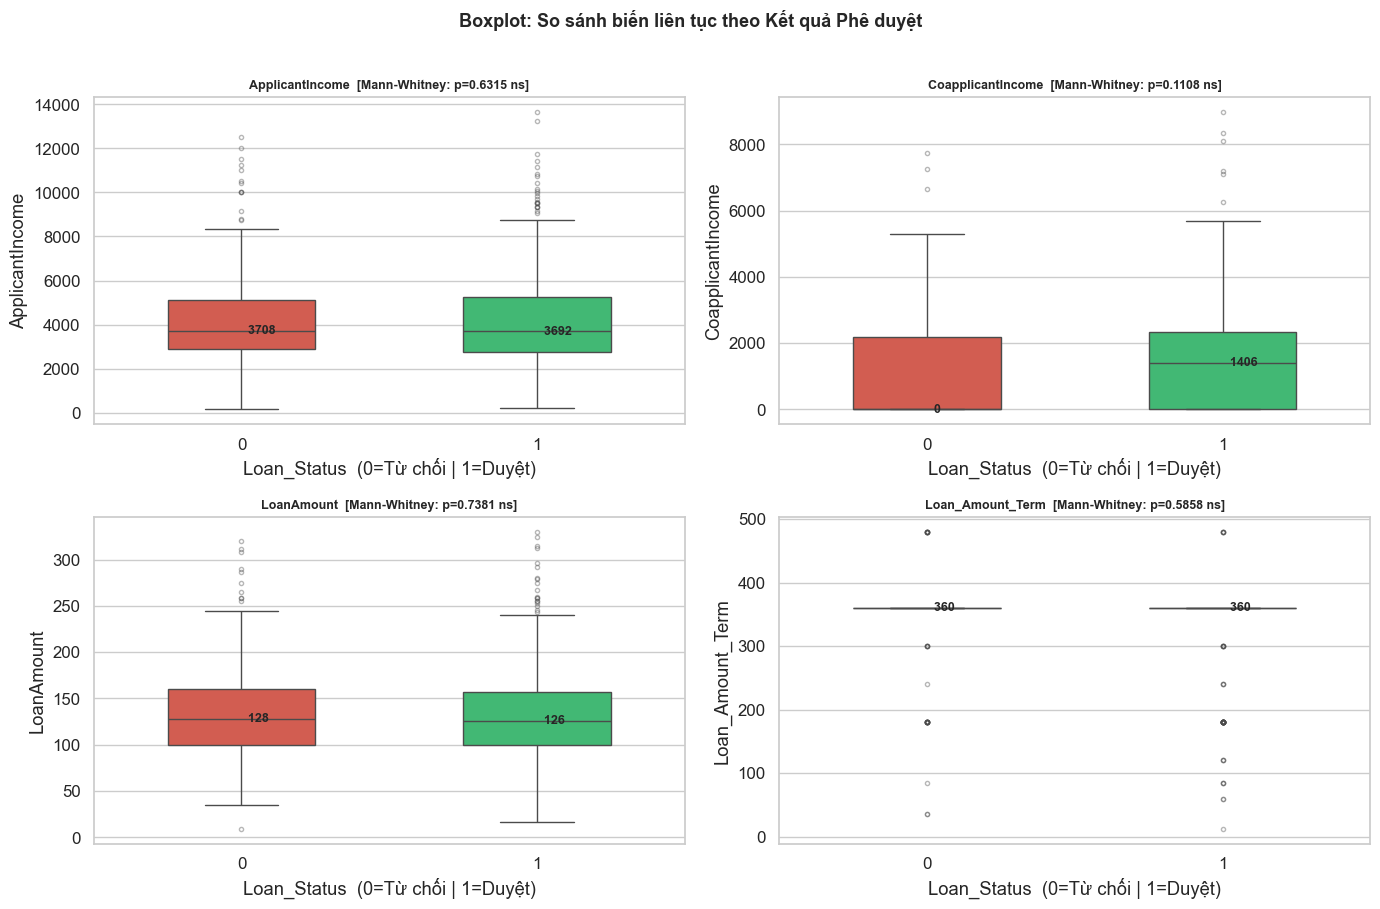

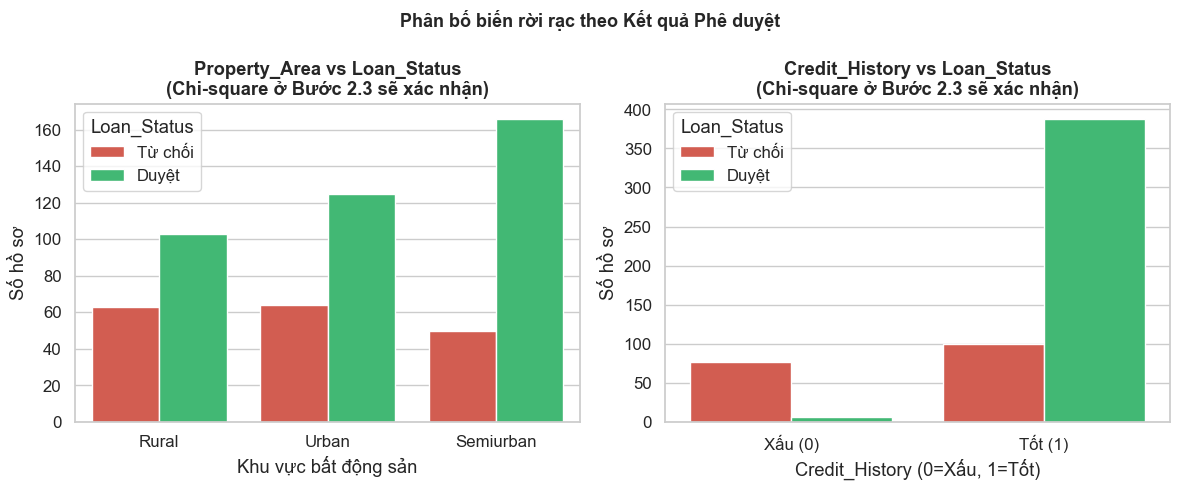

📌 KẾT LUẬN Boxplot: Tất cả 'ns' → median 2 nhóm gần nhau → KNN cần kết hợp nhiều feature


In [14]:
# Biểu đồ hộp 2.5 — Biểu đồ hộp
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    sns.boxplot(data=df_clean, x=TARGET_COL, y=col,
                hue=TARGET_COL,
                palette={0: REJECTED_COLOR, 1: APPROVED_COLOR},
                width=0.5, legend=False,
                flierprops=dict(marker='o', markersize=3, alpha=0.4),
                ax=ax)
    ax.set_xlabel("Loan_Status  (0=Từ chối | 1=Duyệt)")

    for x_val, grp in df_clean.groupby(TARGET_COL):
        median = grp[col].median()
        ax.text(x_val, median, f"  {median:.0f}",
                va='center', fontsize=9, fontweight='bold')

    p_row = df_test[df_test["Cột"] == col]
    if not p_row.empty:
        p_val  = p_row["p-value"].values[0]
        t_name = p_row["Kiểm định"].values[0]
        mark   = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
        ax.set_title(f"{col}  [{t_name}: p={p_val:.4f} {mark}]",
                     fontweight='bold', fontsize=9)

plt.suptitle("Boxplot: So sánh biến liên tục theo Kết quả Phê duyệt",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Property_Area — dùng countplot vì là biến thứ tự
area_labels = {0: 'Rural', 1: 'Urban', 2: 'Semiurban'}
df_plot = df_clean.copy()
df_plot['Property_Area_Label'] = df_plot['Property_Area'].map(area_labels)

sns.countplot(data=df_plot, x='Property_Area_Label',
              hue=TARGET_COL,
              palette={0: REJECTED_COLOR, 1: APPROVED_COLOR},
              order=['Rural', 'Urban', 'Semiurban'],
              ax=axes[0])
axes[0].set_title(f"Property_Area vs Loan_Status\n(Chi-square ở Bước 2.3 sẽ xác nhận)",
                  fontweight='bold')
axes[0].set_xlabel("Khu vực bất động sản")
axes[0].set_ylabel("Số hồ sơ")
axes[0].legend(title='Loan_Status', labels=['Từ chối', 'Duyệt'])

# Credit_History — tương tự
sns.countplot(data=df_clean, x='Credit_History',
              hue=TARGET_COL,
              palette={0: REJECTED_COLOR, 1: APPROVED_COLOR},
              ax=axes[1])
axes[1].set_title("Credit_History vs Loan_Status\n(Chi-square ở Bước 2.3 sẽ xác nhận)",
                  fontweight='bold')
axes[1].set_xlabel("Credit_History (0=Xấu, 1=Tốt)")
axes[1].set_ylabel("Số hồ sơ")
axes[1].set_xticklabels(['Xấu (0)', 'Tốt (1)'])
axes[1].legend(title='Loan_Status', labels=['Từ chối', 'Duyệt'])

plt.suptitle("Phân bố biến rời rạc theo Kết quả Phê duyệt",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("📌 KẾT LUẬN Boxplot: Tất cả 'ns' → median 2 nhóm gần nhau → KNN cần kết hợp nhiều feature")

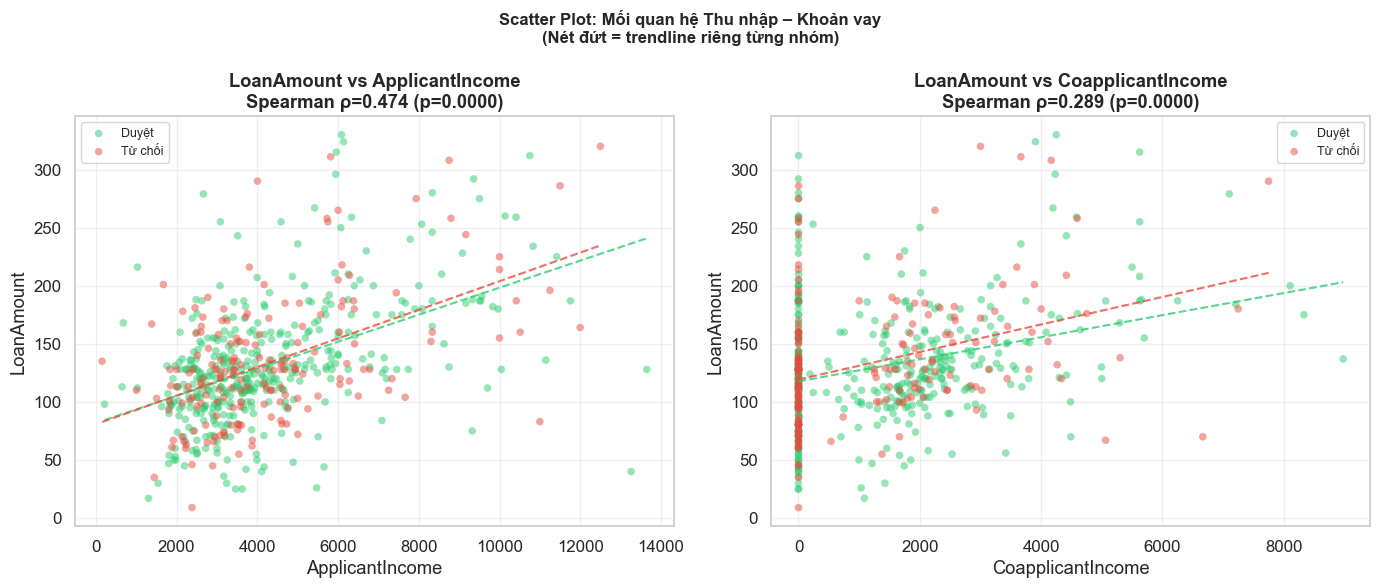

📌 KẾT LUẬN Scatter:
  ApplicantIncome ↔ LoanAmount   : Spearman ρ=0.474
  CoapplicantIncome ↔ LoanAmount : Spearman ρ=0.289
  2 nhóm Duyệt/Từ chối KHÔNG tách cluster → cần thêm Credit_History + Property_Area


In [ ]:
# Bước 2.6 — Biểu đồ phân tán
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (xcol, ycol) in zip(axes, [
        ("ApplicantIncome", "LoanAmount"),
        ("CoapplicantIncome", "LoanAmount")]):

    for status, color, label in [(1, APPROVED_COLOR, "Duyệt"),
                                  (0, REJECTED_COLOR, "Từ chối")]:
        sub = df_clean[df_clean[TARGET_COL] == status]
        ax.scatter(sub[xcol], sub[ycol], c=color, alpha=0.5,
                   s=30, label=label, edgecolors='none')
        # Trendline riêng từng nhóm
        z_fit  = np.polyfit(sub[xcol], sub[ycol], 1)
        x_line = np.linspace(sub[xcol].min(), sub[xcol].max(), 200)
        ax.plot(x_line, np.poly1d(z_fit)(x_line),
                color=color, linewidth=1.5, linestyle='--', alpha=0.8)

    r_s, p_s = stats.spearmanr(df_clean[xcol], df_clean[ycol])
    ax.set_title(f"{ycol} vs {xcol}\nSpearman ρ={r_s:.3f} (p={p_s:.4f})",
                 fontweight='bold')
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Scatter Plot: Mối quan hệ Thu nhập – Khoản vay\n(Nét đứt = trendline riêng từng nhóm)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 KẾT LUẬN Scatter:")
r1, _ = stats.spearmanr(df_clean["ApplicantIncome"], df_clean["LoanAmount"])
r2, _ = stats.spearmanr(df_clean["CoapplicantIncome"], df_clean["LoanAmount"])
print(f"  ApplicantIncome ↔ LoanAmount   : Spearman ρ={r1:.3f}")
print(f"  CoapplicantIncome ↔ LoanAmount : Spearman ρ={r2:.3f}")
print(f"  2 nhóm Duyệt/Từ chối KHÔNG tách cluster → cần thêm Credit_History + Property_Area")

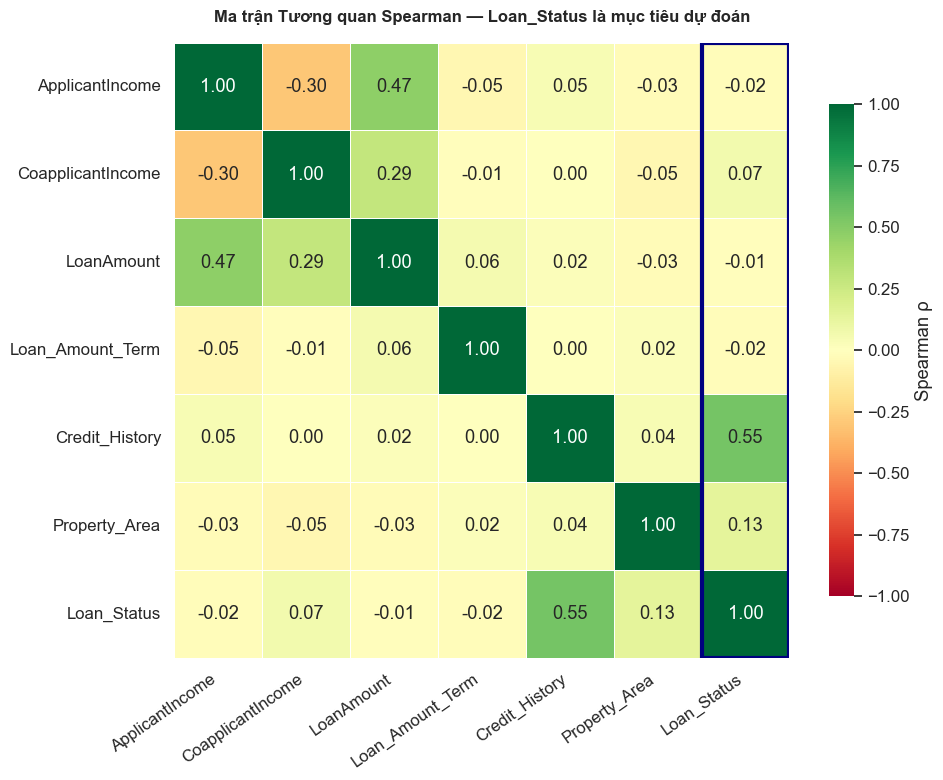

📌 KẾT LUẬN Heatmap:
  Tương quan với Loan_Status (Spearman ρ, giảm dần):
  Credit_History        : ρ = +0.551  ★ Quan trọng nhất
  Property_Area         : ρ = +0.134
  CoapplicantIncome     : ρ = +0.067
  Loan_Amount_Term      : ρ = -0.023
  ApplicantIncome       : ρ = -0.020
  LoanAmount            : ρ = -0.014

  Cảnh báo Multicollinearity (|ρ| > 0.7 giữa các feature):
  ✅ Không phát hiện multicollinearity nghiêm trọng


In [ ]:
#  Bước 2.7 — Heatmap Tương quan (Spearman)
corr_cols   = NUMERIC_COLS + ORDINAL_COLS + [TARGET_COL]
corr_matrix = df_clean[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white', square=True,
    cbar_kws={"shrink": 0.8, "label": "Spearman ρ"},
    ax=ax
)
target_idx = corr_cols.index(TARGET_COL)
ax.add_patch(plt.Rectangle((target_idx, 0), 1, len(corr_cols),
                             fill=False, edgecolor='navy', lw=3))
ax.set_title("Ma trận Tương quan Spearman — Loan_Status là mục tiêu dự đoán",
             fontsize=12, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print("📌 KẾT LUẬN Heatmap:")
print("  Tương quan với Loan_Status (Spearman ρ, giảm dần):")
for feat, r in corr_matrix[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False).items():
    orig = corr_matrix.loc[feat, TARGET_COL]
    tag  = "  ★ Quan trọng nhất" if abs(orig) > 0.3 else ""
    print(f"  {feat:<22}: ρ = {orig:+.3f}{tag}")

print("\n  Cảnh báo Multicollinearity (|ρ| > 0.7 giữa các feature):")
found = False
for i, f1 in enumerate(corr_cols[:-1]):
    for f2 in corr_cols[i+1:-1]:
        r = corr_matrix.loc[f1, f2]
        if abs(r) > 0.7:
            print(f"  ⚠️  {f1} ↔ {f2} : ρ={r:.2f} → cân nhắc bỏ bớt 1 trong Phần 3&4")
            found = True
if not found:
    print("  ✅ Không phát hiện multicollinearity nghiêm trọng")

In [15]:
# Bước 2.8 — Lưu file 
df_clean.to_csv("clean_no_outlier.csv", index=False)
print(f"✔ clean_no_outlier.csv — {df_clean.shape}")
print(f"  Dùng cho Phần 3 (KNN tự code) và Phần 4 (sklearn)")
print(f"  Mất cân bằng: Duyệt={int(df_clean[TARGET_COL].sum())} | Từ chối={int((df_clean[TARGET_COL]==0).sum())}")

✔ clean_no_outlier.csv — (571, 7)
  Dùng cho Phần 3 (KNN tự code) và Phần 4 (sklearn)
  Mất cân bằng: Duyệt=394 | Từ chối=177
